# CRC Bootstrap Stability Analysis

MacSGP on CRC: 50 次 bootstrap 实验稳定性评估

- **Sec 1**: Jaccard 稳定性 + Gene recovery
- **Sec 2**: Loading & Rank 95% 置信区间 (CI)

> 运行顺序：01 → 06 依次执行完毕后，Sec 1 / Sec 2 各图可独立重新运行。

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Nature Communications style
mpl.rcParams.update({
    'font.family'       : 'Helvetica',
    'font.size'         : 7,
    'axes.titlesize'    : 8,
    'axes.labelsize'    : 7,
    'xtick.labelsize'   : 6.5,
    'ytick.labelsize'   : 6.5,
    'axes.linewidth'    : 0.5,
    'xtick.major.width' : 0.5,
    'ytick.major.width' : 0.5,
    'xtick.major.size'  : 2.5,
    'ytick.major.size'  : 2.5,
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'savefig.dpi'       : 300,
    'figure.dpi'        : 150,
})

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
RESULT_PATH   = '/import/home2/share/yqzeng/MacSGP/results/CRC/bootstrap'
ORIGINAL_PATH = '/home/yzengbj/my_project/results/CRC'
FIG_PATH      = os.path.join(RESULT_PATH, 'figures_CI')
os.makedirs(FIG_PATH, exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────
prefix = 'adata_result_bootstrap_'
ALPHA  = 0.05   # → 95% CI
TOP_N  = 100

# ── Cell type lists ───────────────────────────────────────────────────────────
SELECTED_CELLTYPES = [
    'CAF', 'Enterocyte', 'Goblet', 'Macrophage',
    'Myofibroblast', 'Neutrophil', 'Pericytes', 'Plasma',
    'Proliferating Fibroblast', 'Proliferating Immune II',
    'Tumor III', 'Tumor V', 'cDC I', 'vSM',
]

# Programs kept after quality filtering (remove Myofibroblast / Prolif.Imm.II / cDC I)
filtered_cts = [
    'CAF', 'Enterocyte', 'Goblet', 'Macrophage',
    'Neutrophil', #'Pericytes', 
    'Plasma',
    'Proliferating Fibroblast',
    'Tumor III', 'Tumor V', 'vSM',
]

print(f'FIG_PATH: {FIG_PATH}')
print(f'Plotting {len(filtered_cts)} cell types: {filtered_cts}')

FIG_PATH: /import/home2/share/yqzeng/MacSGP/results/CRC/bootstrap/figures_CI
Plotting 10 cell types: ['CAF', 'Enterocyte', 'Goblet', 'Macrophage', 'Neutrophil', 'Plasma', 'Proliferating Fibroblast', 'Tumor III', 'Tumor V', 'vSM']


In [4]:
# ── Load original (non-bootstrap) result ──────────────────────────────────────
adata_orig   = ad.read_h5ad(os.path.join(ORIGINAL_PATH, 'adata_hd_016.h5ad'))
loading_orig = adata_orig.varm['loading']
gene_names   = np.array(adata_orig.var_names)

if hasattr(loading_orig, 'columns'):
    celltype_names   = list(loading_orig.columns)
    loading_orig_arr = loading_orig.values
elif hasattr(loading_orig, 'dtype') and loading_orig.dtype.names:
    celltype_names   = list(loading_orig.dtype.names)
    loading_orig_arr = np.column_stack([loading_orig[ct] for ct in celltype_names])
else:
    celltype_names   = [f'CT_{i}' for i in range(loading_orig.shape[1])]
    loading_orig_arr = np.array(loading_orig)

print(f'Genes: {len(gene_names)},  Cell types: {len(celltype_names)}')
print(f'Available cell types: {celltype_names}')

Genes: 2780,  Cell types: 22
Available cell types: ['CAF', 'CD8 T cell', 'Endothelial', 'Enteric Glial', 'Enterocyte', 'Fibroblast', 'Goblet', 'Lymphatic Endothelial', 'Macrophage', 'Myofibroblast', 'Neutrophil', 'Pericytes', 'Plasma', 'Proliferating Fibroblast', 'Proliferating Immune II', 'Proliferating Macrophages', 'Tuft', 'Tumor III', 'Tumor V', 'cDC I', 'mRegDC', 'vSM']


In [8]:
# ── Load all bootstrap h5ad files ─────────────────────────────────────────────
result_files = sorted([
    f for f in os.listdir(RESULT_PATH)
    if f.startswith(prefix) and f.endswith('.h5ad')
])
print(f'Found {len(result_files)} bootstrap files.')

boot_stack = []
for fname in result_files:
    adata_b = ad.read_h5ad(os.path.join(RESULT_PATH, fname))
    lb = adata_b.varm['loading']
    if hasattr(lb, 'values'):
        arr = lb.values
    elif hasattr(lb, 'dtype') and lb.dtype.names:
        arr = np.column_stack([lb[ct] for ct in celltype_names])
    else:
        arr = np.array(lb)
    boot_stack.append(arr)

boot_stack = np.array(boot_stack)          # (n_boot, n_genes, n_ct)
n_boot, n_genes, n_ct_all = boot_stack.shape
print(f'Bootstrap array shape: {boot_stack.shape}')

# ── Sign correction: align each bootstrap sample with the original ─────────────
for b in range(n_boot):
    for c in range(n_ct_all):
        corr, _ = pearsonr(boot_stack[b, :, c], loading_orig_arr[:, c])
        if corr < 0:
            boot_stack[b, :, c] *= -1

print('Sign correction done.')

Found 50 bootstrap files.
Bootstrap array shape: (50, 2780, 22)
Sign correction done.


---
## Section 1 — Jaccard Stability & Gene Recovery

衡量每个 cell type 的 top-N 基因集在 bootstrap 中的**稳定性**：
- **Jaccard**：bootstrap top-N 与 原始 top-N 的集合重叠率
- **Recovery**：top-50 中每个基因被 bootstrap 重新选中的频率

In [9]:
def jaccard(s1, s2):
    inter = len(s1 & s2)
    union = len(s1 | s2)
    return inter / union if union > 0 else 0

def get_top_genes(loading_arr, gene_names, ct_idx, top_n):
    top_idx = np.argsort(np.abs(loading_arr[:, ct_idx]))[::-1][:top_n]
    return set(gene_names[top_idx])

selected_ct_indices = [(celltype_names.index(ct), ct) for ct in filtered_cts]

results = []
for top_n in [50, 100, 200]:
    for ct_idx, ct_name in selected_ct_indices:
        orig_top = get_top_genes(loading_orig_arr, gene_names, ct_idx, top_n)
        jaccards = [
            jaccard(orig_top, get_top_genes(boot_arr, gene_names, ct_idx, top_n))
            for boot_arr in boot_stack
        ]
        results.append({
            'cell_type'     : ct_name,
            'top_n'         : top_n,
            'mean_jaccard'  : np.mean(jaccards),
            'median_jaccard': np.median(jaccards),
            'std_jaccard'   : np.std(jaccards),
            'jaccards'      : jaccards,
        })

results_df = pd.DataFrame(results)

print('=== Jaccard Stability Summary (Top 50) ===')
print(results_df[results_df['top_n'] == 50][
    ['cell_type', 'mean_jaccard', 'median_jaccard', 'std_jaccard']
].to_string(index=False))

=== Jaccard Stability Summary (Top 50) ===
               cell_type  mean_jaccard  median_jaccard  std_jaccard
                     CAF      0.894454        0.886792     0.031196
              Enterocyte      0.945212        0.960784     0.029345
                  Goblet      0.910516        0.923077     0.035510
              Macrophage      0.919901        0.923077     0.031411
              Neutrophil      0.883860        0.886792     0.034200
                  Plasma      0.849743        0.851852     0.049207
Proliferating Fibroblast      0.859223        0.851852     0.030048
               Tumor III      0.917809        0.923077     0.034828
                 Tumor V      0.911406        0.923077     0.039525
                     vSM      0.860312        0.851852     0.040660


In [10]:
results_df.loc[27]['jaccards']

[0.9323671497584541,
 0.9230769230769231,
 0.9607843137254902,
 0.9323671497584541,
 0.9323671497584541,
 0.9512195121951219,
 0.9607843137254902,
 0.9230769230769231,
 0.941747572815534,
 0.9138755980861244,
 0.9512195121951219,
 0.9512195121951219,
 0.9607843137254902,
 0.941747572815534,
 0.9607843137254902,
 0.941747572815534,
 0.9704433497536946,
 0.941747572815534,
 0.9512195121951219,
 0.941747572815534,
 0.9323671497584541,
 0.9704433497536946,
 0.9230769230769231,
 0.9138755980861244,
 0.9607843137254902,
 0.941747572815534,
 0.9323671497584541,
 0.941747572815534,
 0.9512195121951219,
 0.9512195121951219,
 0.9512195121951219,
 0.9323671497584541,
 0.941747572815534,
 0.941747572815534,
 0.9323671497584541,
 0.9801980198019802,
 0.9607843137254902,
 0.9607843137254902,
 0.9323671497584541,
 0.9323671497584541,
 0.9607843137254902,
 0.941747572815534,
 0.9323671497584541,
 0.8957345971563981,
 0.9801980198019802,
 0.9138755980861244,
 0.9047619047619048,
 0.9607843137254902,
 0

In [11]:
gene_recovery = []
for ct_idx, ct_name in selected_ct_indices:
    orig_top    = get_top_genes(loading_orig_arr, gene_names, ct_idx, TOP_N)
    gene_counts = {g: 0 for g in orig_top}
    for boot_arr in boot_stack:
        boot_top = get_top_genes(boot_arr, gene_names, ct_idx, TOP_N)
        for g in orig_top:
            if g in boot_top:
                gene_counts[g] += 1
    for gene, count in gene_counts.items():
        gene_recovery.append({
            'cell_type'    : ct_name,
            'gene'         : gene,
            'recovery_rate': count / n_boot,
        })

gene_recovery_df = pd.DataFrame(gene_recovery)

core = gene_recovery_df[gene_recovery_df['recovery_rate'] >= 0.8]
print(f'Core genes (recovery >= 80%, top {TOP_N}):')
for _, ct_name in selected_ct_indices:
    n_core = len(core[core['cell_type'] == ct_name])
    print(f'  {ct_name}: {n_core}/{TOP_N}')

Core genes (recovery >= 80%, top 100):
  CAF: 88/100
  Enterocyte: 94/100
  Goblet: 91/100
  Macrophage: 88/100
  Neutrophil: 80/100
  Plasma: 79/100
  Proliferating Fibroblast: 84/100
  Tumor III: 93/100
  Tumor V: 88/100
  vSM: 89/100


In [10]:
gene_recovery_df

,cell_type,gene,recovery_rate
0,CAF,IGFBP3,1.00
1,CAF,ACTA2,1.00
2,CAF,IGFBP5,1.00
3,CAF,LGALS1,1.00
4,CAF,SPARC,1.00
...,...,...,...
995,vSM,MAB21L2,1.00
996,vSM,SELENOM,1.00
997,vSM,CAVIN1,0.90
998,vSM,TGM2,0.62


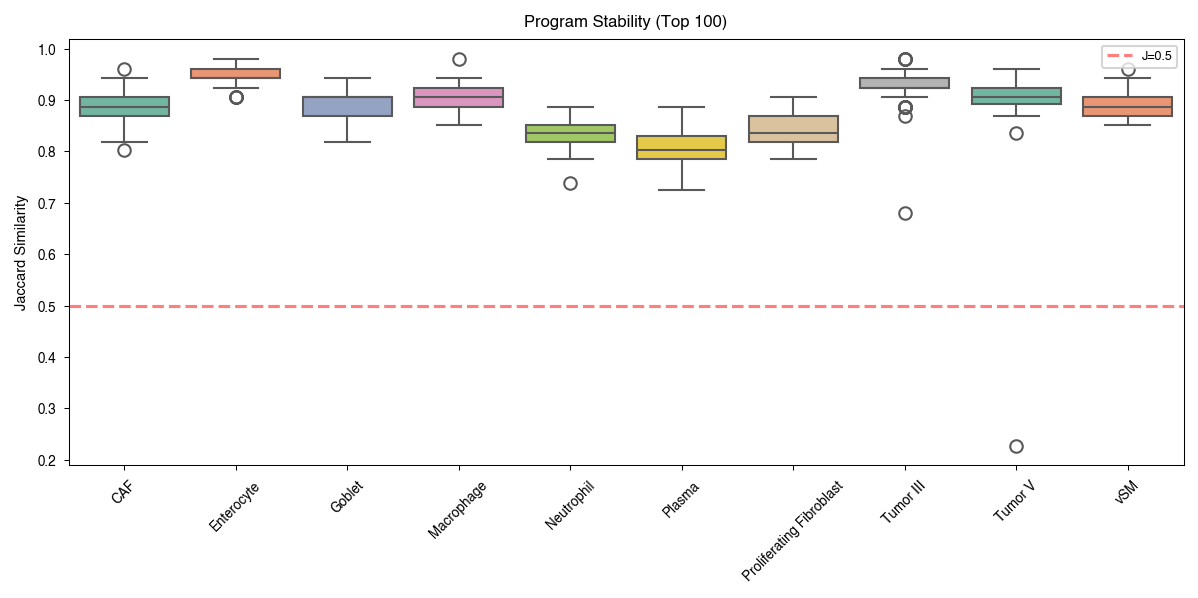

In [8]:
# Fig 1: Jaccard boxplot (top-100)
plot_data = []
for _, row in results_df[results_df['top_n'] == 100].iterrows():
    for j in row['jaccards']:
        plot_data.append({'Cell Type': row['cell_type'], 'Jaccard': j})
plot_df = pd.DataFrame(plot_data)
plot_df = plot_df[plot_df['Cell Type'].isin(filtered_cts)]

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=plot_df, x='Cell Type', y='Jaccard',
            ax=ax, palette='Set2', order=filtered_cts)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='J=0.5')
ax.set_title('Program Stability (Top 100)')
ax.set_ylabel('Jaccard Similarity')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig1_jaccard_boxplot.pdf'), bbox_inches='tight')
plt.show()

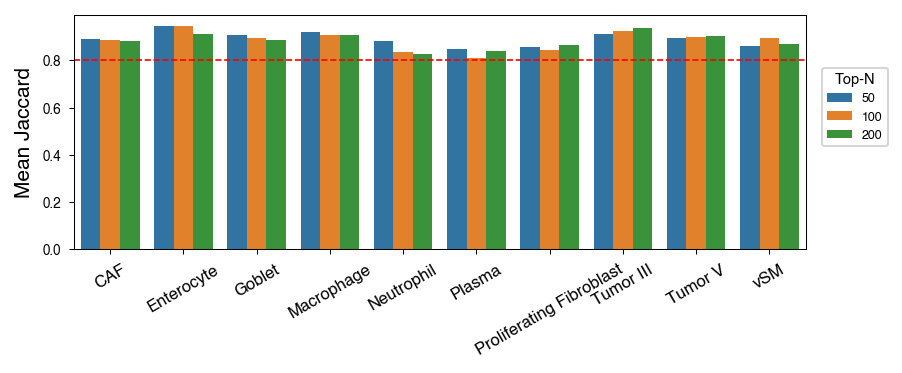

In [9]:
# Fig 2: Mean Jaccard comparison across top-N thresholds
summary = results_df[['cell_type', 'top_n', 'mean_jaccard']].copy()
summary = summary[summary['cell_type'].isin(filtered_cts)]
summary['top_n'] = summary['top_n'].astype(str)

fig, ax = plt.subplots(figsize=(6, 2.5))
sns.barplot(data=summary, x='cell_type', y='mean_jaccard',
            hue='top_n', ax=ax, order=filtered_cts)
ax.axhline(y=0.8, color='Red', linestyle='--', alpha=1, linewidth=0.8)
#ax.set_title('Stability across Top-N')
ax.set_ylabel('Mean Jaccard', fontsize=10)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.legend(title='Top-N', fontsize=6, title_fontsize=7, loc='upper right', bbox_to_anchor=(1.12, 0.8))
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig2_stability_topN.pdf'), bbox_inches='tight')
plt.show()

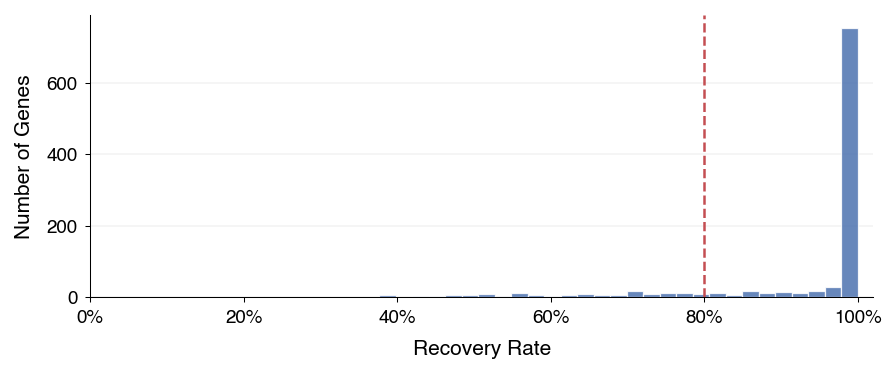

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
fig, ax = plt.subplots(figsize=(6, 2.5), dpi=150)

# ── histogram ──
counts, bins, patches = ax.hist(
    gene_recovery_df['recovery_rate'],
    bins=40,
    edgecolor='white',
    linewidth=0.6,
    color='#4C72B0',
    alpha=0.85,
    zorder=2,
)

# ── 按阈值给 bar 上色：>=0.8 深色，<0.8 浅色 ──
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= 0.8:
        patch.set_facecolor('#4C72B0')   # 红色系，突出高恢复率
        patch.set_alpha(0.85)

# ── 80% 阈值线 ──
ax.axvline(x=0.8, color='#C44E52', linestyle='--', linewidth=1.2, zorder=3)
# ax.text(0.81, ax.get_ylim()[1] * 0.92, '80% threshold',
#         color='#C44E52', fontsize=8, fontstyle='italic', va='top')

# # ── 中位数标注 ──
# median_val = gene_recovery_df['recovery_rate'].median()
# ax.axvline(x=median_val, color='#2D2D2D', linestyle=':', linewidth=1.0, zorder=3)
# ax.text(median_val + 0.01, ax.get_ylim()[1] * 0.78,
#         f'Median = {median_val:.2f}',
#         color='#2D2D2D', fontsize=8, va='top')

# # ── 统计摘要 (右上角) ──
# n_total = len(gene_recovery_df)
# n_above = (gene_recovery_df['recovery_rate'] >= 0.8).sum()
# pct_above = n_above / n_total * 100
# summary_text = (f'n = {n_total}\n'
#                 f'≥ 80%: {n_above} ({pct_above:.1f}%)')
# ax.text(0.97, 0.95, summary_text, transform=ax.transAxes,
#         fontsize=8, va='top', ha='right',
#         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F2F2F2',
#                   edgecolor='#CCCCCC', linewidth=0.6))

# ── axis labels ──
ax.set_xlabel('Recovery Rate', fontsize=10, labelpad=6)
ax.set_ylabel('Number of Genes', fontsize=10, labelpad=6)
ax.set_xlim(0, 1.02)

# ── 清理边框 ──
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── 轻网格 ──
ax.yaxis.grid(True, linestyle='-', alpha=0.15, zorder=0)
ax.set_axisbelow(True)

# ── tick 格式 ──
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.tick_params(labelsize=9)

plt.tight_layout()
# plt.savefig(os.path.join(FIG_PATH, 'fig3_gene_recovery.pdf'),
#             bbox_inches='tight', dpi=300)
plt.show()

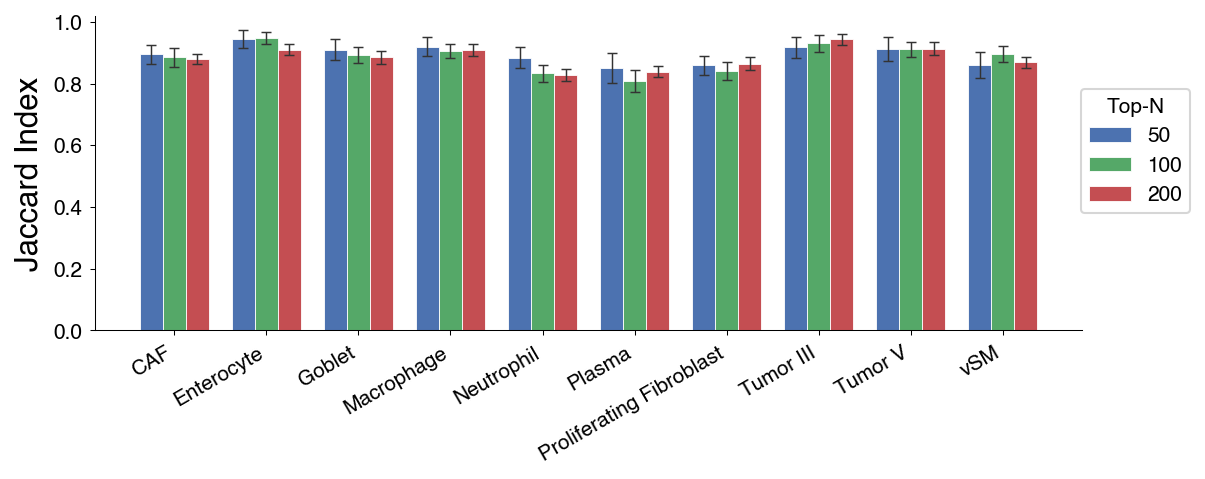

In [16]:
# ── Fig 1b: Jaccard mean ± SD  —  Top-50 / 100 / 200 grouped bar with error bars
top_n_vals = [50, 100, 200]
colors     = ['#4C72B0', '#55A868', '#C44E52']
n_cts      = len(filtered_cts)
x          = np.arange(n_cts)
w          = 0.25

fig, ax = plt.subplots(figsize=(8, 3.2))
for i, (top_n, color) in enumerate(zip(top_n_vals, colors)):
    sub = (results_df[results_df['top_n'] == top_n]
           .pipe(lambda d: d[d['cell_type'].isin(filtered_cts)])
           .set_index('cell_type')
           .loc[filtered_cts])
    ax.bar(
        x + (i - 1) * w, sub['mean_jaccard'], yerr=sub['std_jaccard'],
        width=w, capsize=2.5, label=f'{top_n}',
        color=color, edgecolor='white', linewidth=0.4,
        error_kw=dict(elinewidth=0.7, capthick=0.7, ecolor='#333333'),
    )

#ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=10)
ax.set_ylabel('Jaccard Index', fontsize=15)
ax.set_ylim(0, 1.02)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, title='Top-N', title_fontsize=10, 
          loc='upper right', bbox_to_anchor=(1.12, 0.8), 
          )
plt.tight_layout()
#plt.savefig(os.path.join(FIG_PATH, 'fig1b_jaccard_errorbar_topN.pdf'), bbox_inches='tight')
plt.show()

In [21]:
results_df

,cell_type,top_n,mean_jaccard,median_jaccard,std_jaccard,jaccards
0,CAF,50,0.892356,0.886792,0.032692,"[0.8181818181818182, 0.8181818181818182, 0.886..."
1,Enterocyte,50,0.943732,0.960784,0.030370,"[0.8867924528301887, 0.9607843137254902, 0.923..."
2,Goblet,50,0.909091,0.923077,0.036395,"[0.8518518518518519, 0.9230769230769231, 0.923..."
3,Macrophage,50,0.919901,0.923077,0.031411,"[0.8867924528301887, 0.9230769230769231, 0.851..."
4,Neutrophil,50,0.882380,0.886792,0.032392,"[0.8867924528301887, 0.8867924528301887, 0.923..."
5,Plasma,50,0.849743,0.851852,0.049207,"[0.8867924528301887, 0.8518518518518519, 0.851..."
6,Proliferating Fibroblast,50,0.858549,0.851852,0.030578,"[0.8181818181818182, 0.8181818181818182, 0.851..."
7,Tumor III,50,0.910598,0.923077,0.060707,"[0.5625, 0.9230769230769231, 0.923076923076923..."
8,Tumor V,50,0.896398,0.923077,0.115493,"[0.13636363636363635, 0.9607843137254902, 0.92..."
9,vSM,50,0.861684,0.851852,0.040372,"[0.8867924528301887, 0.8867924528301887, 0.818..."


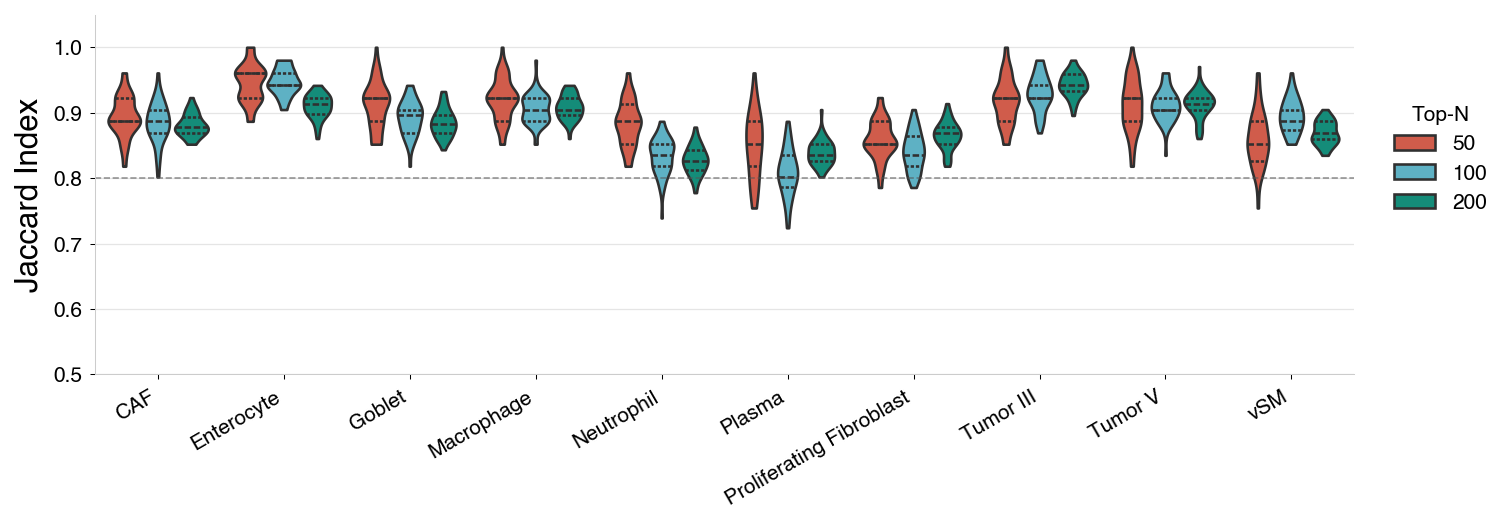

In [12]:
# ── Fig 1c: Jaccard — grouped violin plot (beautified) ────────────────────────
jac_long = []
for _, row in results_df.iterrows():
    if row['cell_type'] not in filtered_cts:
        continue
    for j in row['jaccards']:
        jac_long.append({
            'cell_type': row['cell_type'],
            'top_n'    : str(int(row['top_n'])),
            'Jaccard'  : j,
        })
jac_long_df = pd.DataFrame(jac_long)

palette = ['#E64B35', '#4DBBD5', '#00A087']

fig, ax = plt.subplots(figsize=(10, 3.5))

sns.violinplot(
    data=jac_long_df,
    x='cell_type', y='Jaccard',
    hue='top_n', hue_order=['50', '100', '200'],
    order=filtered_cts,
    palette=palette,
    inner='quartile',   # 三条横线：Q25 / 中位数 / Q75
    cut=0,
    #linewidth=0,
    ax=ax,
)

# # 半透明 violin body
# for patch in ax.collections:
#     patch.set_alpha(0.78)

# # 每组 violin 有 3 条线：Q25 / median / Q75（顺序固定）
# # 中位线（每组第 2 条，index % 3 == 1）加粗，Q25/Q75 细虚线
# for i, line in enumerate(ax.lines):
#     if i % 3 == 1:          # 中位数
#         line.set_color('white')
#         line.set_linewidth(2.0)
#         line.set_linestyle('-')
#     else:                   # Q25 / Q75
#         line.set_color('white')
#         line.set_linewidth(0.9)
#         line.set_linestyle('--')

ax.axhline(y=0.8, color='#555555', linestyle='--', linewidth=0.8, alpha=0.6)
ax.yaxis.grid(True, color='#E5E5E5', linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0.5, 1.05)
ax.set_xticks(range(len(filtered_cts)))
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=10)
ax.set_ylabel('Jaccard Index', fontsize=15)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.legend(fontsize=10, title='Top-N', title_fontsize=10,
          loc='upper right', bbox_to_anchor=(1.12, 0.8),
          framealpha=0.9, edgecolor='none')
plt.tight_layout()
#plt.savefig(os.path.join(FIG_PATH, 'fig1c_jaccard_violin.pdf'), bbox_inches='tight')
plt.show()

In [1]:
# transform cmap to color list for seaborn.violinplot
cmap = plt.cm.get_cmap('tab20', n_cts)
color_list = [cmap(i) for i in range(n_cts)]

NameError: name 'plt' is not defined

In [37]:
recovery_array = np.array([gene_counts[g] for g in orig_top])

In [40]:
recovery_array.mean()

46.485

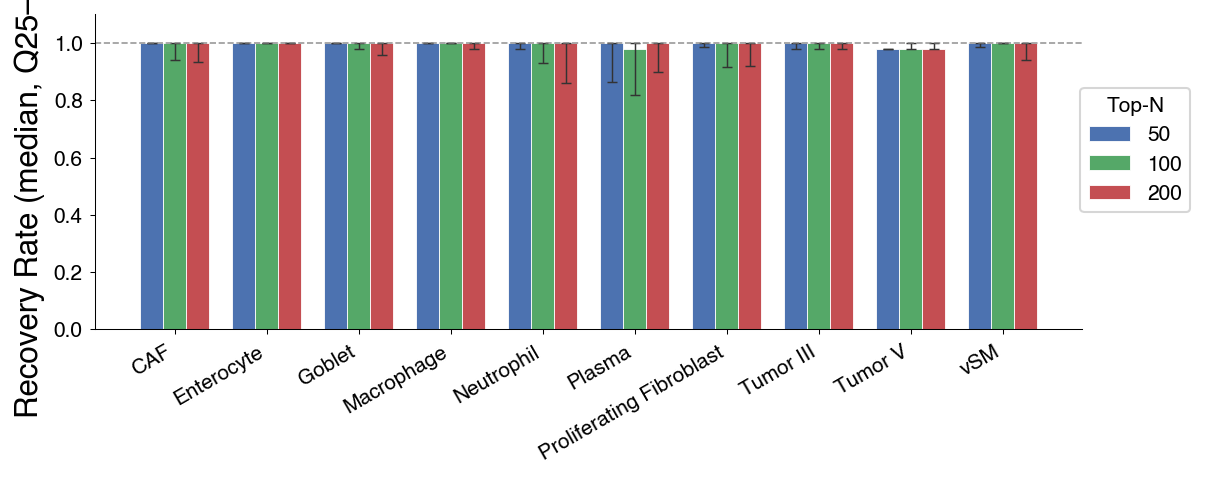

In [12]:
# ── Fig 3c: Recovery Rate — barplot, median + Q25/Q75 as asymmetric error bars
top_n_vals = [50, 100, 200]
colors     = ['#4C72B0', '#55A868', '#C44E52']

rec_q_records = []
for top_n in top_n_vals:
    for ct_idx, ct_name in selected_ct_indices:
        orig_top    = get_top_genes(loading_orig_arr, gene_names, ct_idx, top_n)
        gene_counts = {g: 0 for g in orig_top}
        for boot_arr in boot_stack:
            boot_top = get_top_genes(boot_arr, gene_names, ct_idx, top_n)
            for g in orig_top:
                if g in boot_top:
                    gene_counts[g] += 1
        rates = np.array([count / n_boot for count in gene_counts.values()])
        rec_q_records.append({
            'cell_type': ct_name,
            'top_n'    : top_n,
            'median'   : np.median(rates),
            'q25'      : np.percentile(rates, 25),
            'q75'      : np.percentile(rates, 75),
        })

rec_q_df = pd.DataFrame(rec_q_records)

n_cts = len(filtered_cts)
x     = np.arange(n_cts)
w     = 0.25

fig, ax = plt.subplots(figsize=(8, 3.2))
for i, (top_n, color) in enumerate(zip(top_n_vals, colors)):
    sub = (rec_q_df[rec_q_df['top_n'] == top_n]
           .pipe(lambda d: d[d['cell_type'].isin(filtered_cts)])
           .set_index('cell_type')
           .loc[filtered_cts])
    lower = sub['median'] - sub['q25']   # 下方 error = median - Q25
    upper = sub['q75']   - sub['median'] # 上方 error = Q75 - median
    ax.bar(
        x + (i - 1) * w, sub['median'],
        yerr=[lower.values, upper.values],
        width=w, capsize=2.5, label=f'{top_n}',
        color=color, edgecolor='white', linewidth=0.4,
        error_kw=dict(elinewidth=0.7, capthick=0.7, ecolor='#333333'),
    )

ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=10)
ax.set_ylabel('Recovery Rate (median, Q25–Q75)', fontsize=15)
ax.set_ylim(0, 1.1)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, title='Top-N', title_fontsize=10,
          loc='upper right', bbox_to_anchor=(1.12, 0.8))
plt.tight_layout()
#plt.savefig(os.path.join(FIG_PATH, 'fig3c_recovery_barplot_topN.pdf'), bbox_inches='tight')
plt.show()

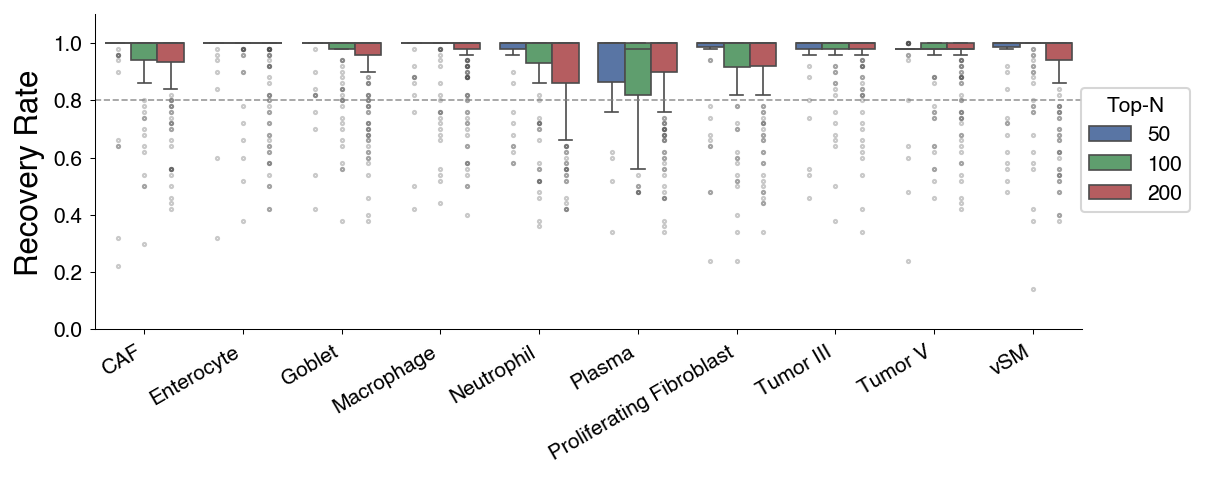

In [11]:
# ── Fig 3d: Recovery Rate — grouped boxplot (Top-50 / 100 / 200) ──────────────
top_n_vals = [50, 100, 200]

rec_long = []
for top_n in top_n_vals:
    for ct_idx, ct_name in selected_ct_indices:
        orig_top    = get_top_genes(loading_orig_arr, gene_names, ct_idx, top_n)
        gene_counts = {g: 0 for g in orig_top}
        for boot_arr in boot_stack:
            boot_top = get_top_genes(boot_arr, gene_names, ct_idx, top_n)
            for g in orig_top:
                if g in boot_top:
                    gene_counts[g] += 1
        for g, count in gene_counts.items():
            rec_long.append({
                'cell_type'    : ct_name,
                'top_n'        : str(top_n),
                'recovery_rate': count / n_boot,
            })

rec_long_df = pd.DataFrame(rec_long)

fig, ax = plt.subplots(figsize=(8, 3.2))
sns.boxplot(
    data=rec_long_df[rec_long_df['cell_type'].isin(filtered_cts)],
    x='cell_type', y='recovery_rate',
    hue='top_n', hue_order=['50', '100', '200'],
    order=filtered_cts,
    palette=['#4C72B0', '#55A868', '#C44E52'],
    linewidth=0.8,
    flierprops=dict(marker='o', markersize=1.5, alpha=0.3),
    ax=ax,
)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.8)
ax.set_xticks(range(len(filtered_cts)))
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=10)
ax.set_ylabel('Recovery Rate', fontsize=15)
ax.set_ylim(0, 1.1)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, title='Top-N', title_fontsize=10,
          loc='upper right', bbox_to_anchor=(1.12, 0.8))
plt.tight_layout()
#plt.savefig(os.path.join(FIG_PATH, 'fig3d_recovery_boxplot.pdf'), bbox_inches='tight')
plt.show()

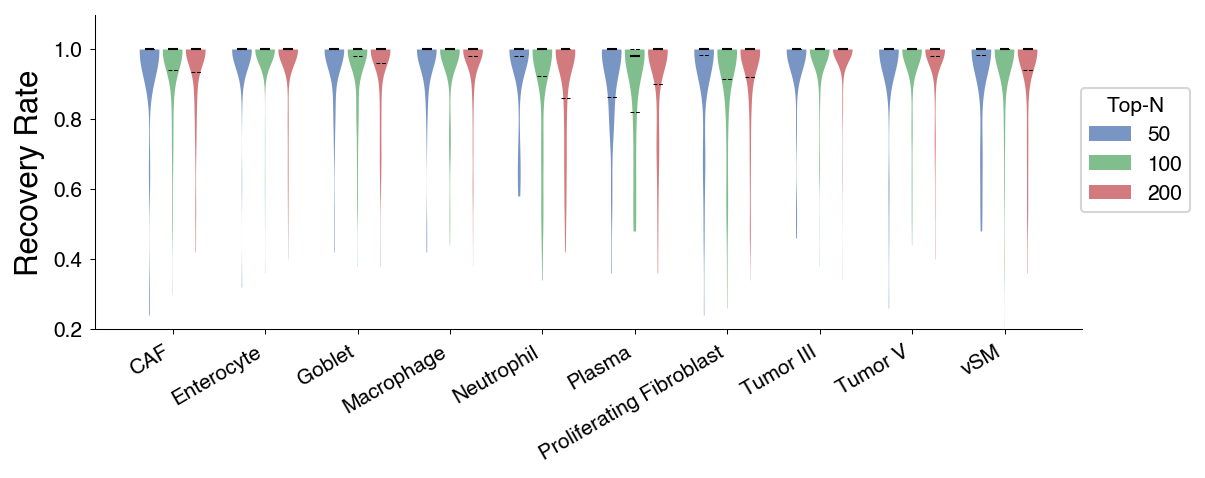

In [13]:
# ── Fig 3e: Recovery Rate — plt.violinplot, grouped by cell type ──────────────
import matplotlib.patches as mpatches

top_n_vals = [50, 100, 200]
colors     = ['#4C72B0', '#55A868', '#C44E52']

# 构建数据
rec_long = []
for top_n in top_n_vals:
    for ct_idx, ct_name in selected_ct_indices:
        orig_top    = get_top_genes(loading_orig_arr, gene_names, ct_idx, top_n)
        gene_counts = {g: 0 for g in orig_top}
        for boot_arr in boot_stack:
            boot_top = get_top_genes(boot_arr, gene_names, ct_idx, top_n)
            for g in orig_top:
                if g in boot_top:
                    gene_counts[g] += 1
        for g, count in gene_counts.items():
            rec_long.append({
                'cell_type'    : ct_name,
                'top_n'        : top_n,
                'recovery_rate': count / n_boot,
            })
rec_long_df = pd.DataFrame(rec_long)

n_cts = len(filtered_cts)
x     = np.arange(n_cts)
w     = 0.25

fig, ax = plt.subplots(figsize=(8, 3.2))

for i, (top_n, color) in enumerate(zip(top_n_vals, colors)):
    violin_data = [
        rec_long_df[
            (rec_long_df['top_n'] == top_n) &
            (rec_long_df['cell_type'] == ct)
        ]['recovery_rate'].values
        for ct in filtered_cts
    ]
    positions = x + (i - 1) * w

    parts = ax.violinplot(
        violin_data,
        positions=positions,
        widths=w * 0.85,
        showmedians=True,
        showextrema=False,
        quantiles=[[0.25, 0.75]] * n_cts,
    )

    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('none')
        pc.set_alpha(0.75)

    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.0)
    parts['cquantiles'].set_color('black')
    parts['cquantiles'].set_linewidth(0.5)
    parts['cquantiles'].set_linestyle('--')

handles = [mpatches.Patch(facecolor=c, alpha=0.75, label=str(n))
           for c, n in zip(colors, top_n_vals)]

ax.set_xticks(x)
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0.2, 1.1)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=10)
ax.set_ylabel('Recovery Rate', fontsize=15)

ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(handles=handles, fontsize=10, title='Top-N', title_fontsize=10,
          loc='upper right', bbox_to_anchor=(1.12, 0.8))
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig3e_recovery_violin.pdf'), bbox_inches='tight')
plt.show()

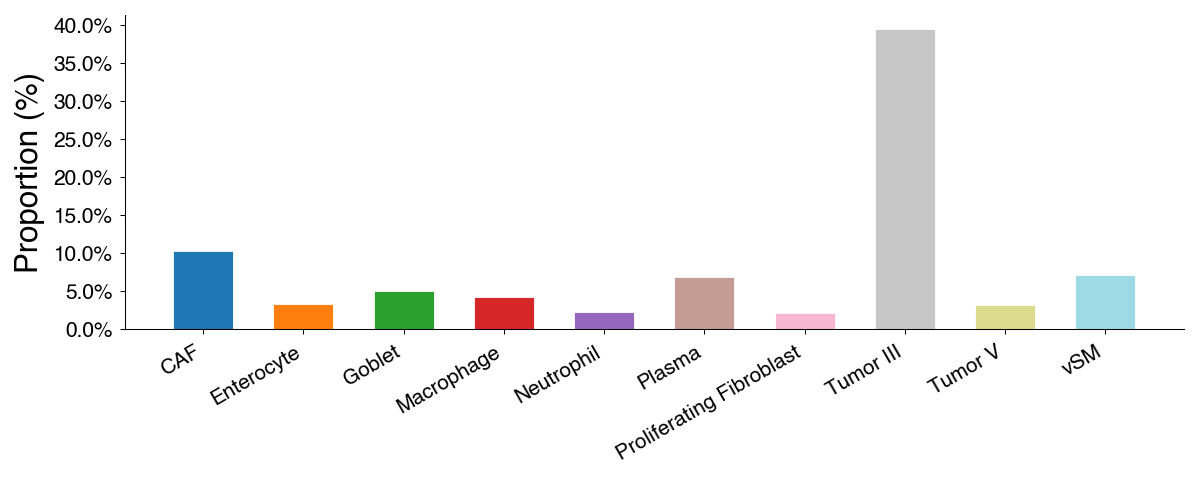

In [53]:
# ── Cell type relative proportion (sum across spots, normalized) ───────────────
prop = adata_orig.obsm['proportion']
if hasattr(prop, 'columns'):
    prop_df = prop
else:
    prop_df = pd.DataFrame(prop, columns=celltype_names, index=adata_orig.obs_names)

colors = plt.cm.get_cmap('tab20', n_cts)
color_list = [colors(i) for i in range(n_cts)]

sum_prop  = prop_df.sum()
rel_prop  = (sum_prop / sum_prop.sum() * 100).loc[filtered_cts]  # 单位：%
rel_prop = rel_prop[filtered_cts]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(
    range(len(filtered_cts)), rel_prop.values, color = color_list,
     edgecolor='white', linewidth=0.4, width=0.6,
)
ax.set_xticks(range(len(filtered_cts)))
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels([f'{y:.1f}%' for y in ax.get_yticks()], fontsize=10)
ax.set_ylabel('Proportion (%)', fontsize=15)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig(os.path.join(FIG_PATH, 'fig_proportion_bar.pdf'), bbox_inches='tight')
plt.show()

In [25]:
adata_orig

AnnData object with n_obs × n_vars = 137051 × 2780
    obs: 'in_tissue', 'array_row', 'array_col', 'library_size', 'alpha'
    var: 'gene_ids', 'feature_types', 'genome', 'gamma'
    uns: 'Spatial_Net', 'log1p', 'spatial'
    obsm: 'count', 'factor', 'latent', 'proportion', 'spatial'
    varm: 'loading'

In [28]:
gene_recovery_df

,cell_type,gene,recovery_rate
0,CAF,LMNA,0.30
1,CAF,MFGE8,1.00
2,CAF,ITGA11,0.76
3,CAF,COL11A1,1.00
4,CAF,TIMP3,1.00
...,...,...,...
995,vSM,IGHG1,1.00
996,vSM,PTGER3,1.00
997,vSM,SELENOM,1.00
998,vSM,KCNMA1,1.00


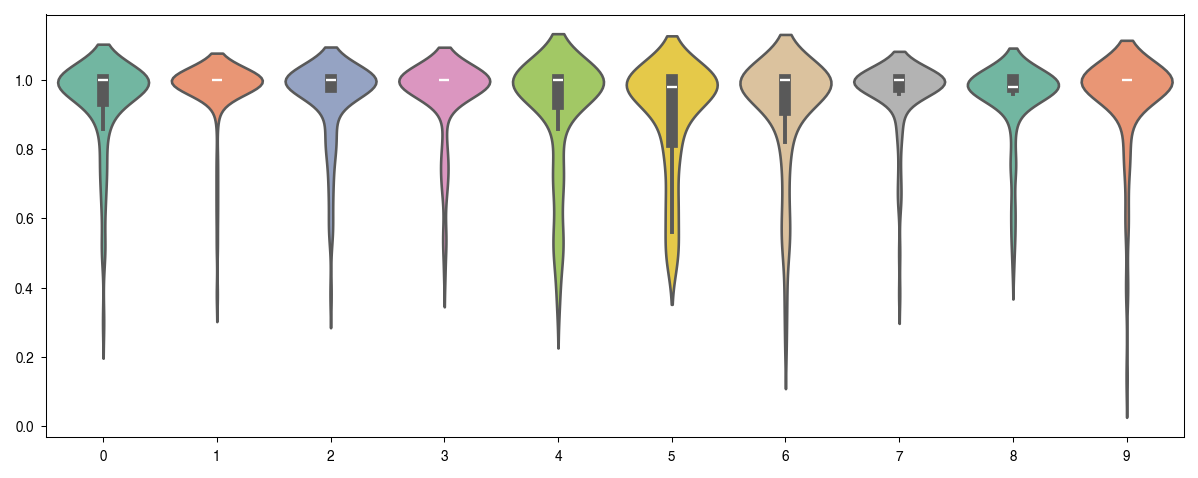

In [30]:
# ── Fig 3b: Recovery rate violin per cell type ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.2))
violin_data = [
    gene_recovery_df[gene_recovery_df['cell_type'] == ct]['recovery_rate'].values
    for ct in filtered_cts
]
ax = sns.violinplot(data=violin_data, palette='Set2', ax=ax)

plt.tight_layout()
#plt.savefig(os.path.join(FIG_PATH, 'fig3b_gene_recovery_violin
#            , bbox_inches='tight'), dpi=300)
plt.show()

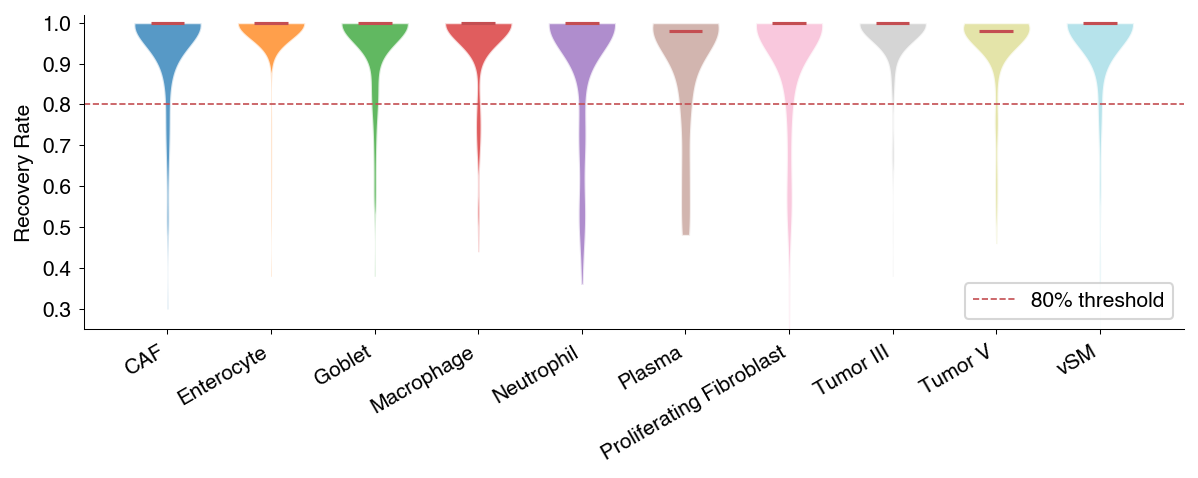

In [10]:
# ── Fig 3b: Recovery rate violin per cell type ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.2))
violin_data = [
    gene_recovery_df[gene_recovery_df['cell_type'] == ct]['recovery_rate'].values
    for ct in filtered_cts
]
cmap = plt.cm.get_cmap('tab20', n_cts)
parts = ax.violinplot(
    violin_data,
    positions=np.arange(n_cts),
    showmedians=True, showextrema=False, widths=0.65,
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(cmap(i))
    pc.set_edgecolor('white')
    pc.set_alpha(0.75)
parts['cmedians'].set_color('#C44E52')
parts['cmedians'].set_linewidth(1.5)
# for key in ('cmins', 'cmaxes', 'cbars'):
#     parts[key].set_linewidth(0.8)
#     parts[key].set_color('#333333')

ax.axhline(y=0.8, color='#C44E52', linestyle='--', linewidth=0.8, label='80% threshold')
ax.set_xticks(np.arange(n_cts))
ax.set_xticklabels(filtered_cts, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Recovery Rate', fontsize=10)
ax.set_ylim(0.25, 1.02)
ax.set_yticklabels([f'{y:.1f}' for y in ax.get_yticks()], fontsize=10)
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig3b_recovery_violin.pdf'), bbox_inches='tight')
plt.show()

---
## Section 2 — Confidence Interval Analysis

基于 50 次 bootstrap 计算每个基因 × cell type 的 **95% CI**：
- **Loading CI**：bootstrap loading 的 2.5% ~ 97.5% 分位数
- **Rank CI**：按 |loading| 降序排名的置信区间（rank=1 最重要）

> 先运行 Cell 14（CI 计算），再运行各图 Cell。

In [ ]:
lo_pct = ALPHA / 2 * 100        # 2.5
hi_pct = (1 - ALPHA / 2) * 100  # 97.5

# ── Loading CI ────────────────────────────────────────────────────────────────
loading_ci_lo = np.percentile(boot_stack, lo_pct, axis=0)  # (n_genes, n_ct)
loading_ci_hi = np.percentile(boot_stack, hi_pct, axis=0)
loading_mean  = np.mean(boot_stack, axis=0)
loading_std   = np.std(boot_stack, axis=0)
ci_width      = loading_ci_hi - loading_ci_lo

# ── Rank CI ───────────────────────────────────────────────────────────────────
boot_ranks = np.zeros_like(boot_stack, dtype=int)
for b in range(n_boot):
    for c in range(n_ct_all):
        order          = np.argsort(np.abs(boot_stack[b, :, c]))[::-1]
        ranks          = np.empty_like(order)
        ranks[order]   = np.arange(1, n_genes + 1)
        boot_ranks[b, :, c] = ranks

rank_ci_lo  = np.percentile(boot_ranks, lo_pct, axis=0)
rank_ci_hi  = np.percentile(boot_ranks, hi_pct, axis=0)
rank_median = np.median(boot_ranks, axis=0)

print('CI computation done.')
print(f'  loading CI shape : {loading_ci_lo.shape}')
print(f'  boot_ranks shape : {boot_ranks.shape}')

CI computation done.
  loading CI shape : (2780, 22)
  boot_ranks shape : (50, 2780, 22)


In [ ]:
# Fig 4: Forest plot (loading + 95% CI) — one figure per cell type
# Red diamond = original loading; blue circle = bootstrap mean
show_n = 30

for ct_name in filtered_cts:
    ct_idx    = celltype_names.index(ct_name)
    orig_load = loading_orig_arr[:, ct_idx]
    top_idx   = np.argsort(np.abs(orig_load))[::-1][:show_n]

    fig, ax = plt.subplots(figsize=(5, show_n * 0.32 + 1.2))
    for i, gi in enumerate(top_idx):
        ci_l = loading_ci_lo[gi, ct_idx]
        ci_h = loading_ci_hi[gi, ct_idx]
        ax.plot([ci_l, ci_h], [i, i], color='steelblue',
                linewidth=2, solid_capstyle='round')
        ax.scatter(loading_mean[gi, ct_idx], i,
                   color='steelblue', s=30, zorder=5)
        ax.scatter(orig_load[gi], i,
                   color='red', s=25, marker='D', zorder=6)

    ax.set_yticks(range(show_n))
    ax.set_yticklabels([gene_names[gi] for gi in top_idx])
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.invert_yaxis()
    ax.set_xlabel('Loading Value')
    ax.set_title(f'{ct_name}  |  Top {show_n} Loading + 95% CI')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_PATH, f'fig4_forest_{ct_name}.pdf'),
                bbox_inches='tight')
    plt.show()

print('Forest plots saved.')

In [ ]:
# Fig 5: Rank CI — one figure per cell type
# green = rank CI entirely within Top-N (stable)
# orange = borderline (CI straddles Top-N cutoff)
# red = unstable (rank CI lower bound > Top-N)
show_n = 30
TOP_N=50

for ct_name in filtered_cts:
    ct_idx    = celltype_names.index(ct_name)
    orig_load = loading_orig_arr[:, ct_idx]
    top_idx   = np.argsort(np.abs(orig_load))[::-1][:show_n]

    fig, ax = plt.subplots(figsize=(5, show_n * 0.32 + 1.2))
    for i, gi in enumerate(top_idx):
        r_lo  = rank_ci_lo[gi, ct_idx]
        r_hi  = rank_ci_hi[gi, ct_idx]
        r_med = rank_median[gi, ct_idx]
        color = 'green' if r_hi <= TOP_N else ('orange' if r_lo <= TOP_N else 'red')
        ax.plot([r_lo, r_hi], [i, i], color=color,
                linewidth=2.5, solid_capstyle='round')
        ax.scatter(r_med, i, color=color, s=30, zorder=5)

    ax.axvline(x=TOP_N, color='red', linestyle='--', alpha=0.6,
               label=f'Top-{TOP_N} cutoff')
    ax.set_yticks(range(show_n))
    ax.set_yticklabels([gene_names[gi] for gi in top_idx])
    ax.invert_yaxis()
    ax.set_xlabel('Rank  (1 = most important)')
    ax.set_title(f'{ct_name}  |  Rank 95% CI')
    ax.legend(loc='lower right', fontsize=6)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_PATH, f'fig5_rank_CI_{ct_name}.pdf'),
                bbox_inches='tight')
    plt.show()

print('Rank CI plots saved.')

In [ ]:
# Fig 7: |loading| vs CI width scatter — one panel per cell type
ncols = min(3, len(filtered_cts))
nrows = (len(filtered_cts) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for idx, ct_name in enumerate(filtered_cts):
    ct_idx   = celltype_names.index(ct_name)
    abs_load = np.abs(loading_orig_arr[:, ct_idx])
    width    = ci_width[:, ct_idx]
    top_idx  = np.argsort(abs_load)[::-1][:TOP_N]
    is_top   = np.zeros(n_genes, dtype=bool)
    is_top[top_idx] = True

    ax = axes[idx]
    ax.scatter(abs_load[~is_top], width[~is_top],
               s=3, alpha=0.2, color='gray', label='Other')
    ax.scatter(abs_load[is_top], width[is_top],
               s=15, alpha=0.7, color='steelblue', label=f'Top-{TOP_N}')
    for gi in top_idx[:10]:
        ax.annotate(gene_names[gi], (abs_load[gi], width[gi]),
                    fontsize=6, alpha=0.8)
    ax.set_xlabel('|Loading|')
    ax.set_ylabel('95% CI Width')
    ax.set_title(ct_name)
    ax.legend(fontsize=6)

for idx in range(len(filtered_cts), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Loading Magnitude vs Bootstrap Uncertainty', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig7_magnitude_vs_uncertainty.pdf'),
            bbox_inches='tight')
plt.show()

In [ ]:
# Fig 8: Significant gene count by criterion
sig_records = []
for ct_idx, ct_name in [(celltype_names.index(ct), ct) for ct in filtered_cts]:
    ci_excl = (loading_ci_lo[:, ct_idx] > 0) | (loading_ci_hi[:, ct_idx] < 0)
    top_set = set(np.argsort(np.abs(loading_orig_arr[:, ct_idx]))[::-1][:TOP_N])
    is_top  = np.array([i in top_set for i in range(n_genes)])
    r_stab  = rank_ci_hi[:, ct_idx] <= TOP_N
    sig_records.append({
        'Cell Type'         : ct_name,
        'CI excl 0'         : int(ci_excl.sum()),
        f'Rank<=TOP_N'      : int((is_top & r_stab).sum()),
        'Both'              : int((is_top & r_stab & ci_excl).sum()),
    })

sig_df = pd.DataFrame(sig_records)
print(sig_df.to_string(index=False))

x = np.arange(len(filtered_cts))
w = 0.25
fig, ax = plt.subplots(figsize=(max(6, len(filtered_cts) * 1.2), 3.5))
ax.bar(x - w, sig_df['CI excl 0'],      w, label='CI excl 0',    color='#4C72B0')
ax.bar(x,     sig_df['Rank<=TOP_N'],     w, label=f'Rank<={TOP_N}', color='#55A868')
ax.bar(x + w, sig_df['Both'],            w, label='Both',          color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(sig_df['Cell Type'], rotation=45, ha='right')
ax.set_ylabel('# Genes')
ax.set_title(f'Significant Genes from Top-{TOP_N}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig8_significant_gene_count.pdf'),
            bbox_inches='tight')
plt.show()

In [ ]:
# Save per-cell-type CI tables and gene recovery CSV
for ct_name in filtered_cts:
    ct_idx    = celltype_names.index(ct_name)
    orig_load = loading_orig_arr[:, ct_idx]
    top_idx   = np.argsort(np.abs(orig_load))[::-1][:TOP_N]

    table = pd.DataFrame({
        'gene'             : gene_names[top_idx],
        'original_rank'    : np.arange(1, TOP_N + 1),
        'loading_original' : orig_load[top_idx],
        'loading_boot_mean': loading_mean[top_idx, ct_idx],
        'loading_boot_std' : loading_std[top_idx, ct_idx],
        'loading_CI_lo'    : loading_ci_lo[top_idx, ct_idx],
        'loading_CI_hi'    : loading_ci_hi[top_idx, ct_idx],
        'CI_width'         : ci_width[top_idx, ct_idx],
        'rank_median'      : rank_median[top_idx, ct_idx].astype(int),
        'rank_CI_lo'       : rank_ci_lo[top_idx, ct_idx].astype(int),
        'rank_CI_hi'       : rank_ci_hi[top_idx, ct_idx].astype(int),
        'CI_excludes_zero' : ((loading_ci_lo[top_idx, ct_idx] > 0) |
                              (loading_ci_hi[top_idx, ct_idx] < 0)),
        'rank_stable'      : rank_ci_hi[top_idx, ct_idx] <= TOP_N,
    })
    table.to_csv(os.path.join(FIG_PATH, f'CI_table_{ct_name}.csv'), index=False)

gene_recovery_df.to_csv(
    os.path.join(RESULT_PATH, 'gene_recovery_selected.csv'), index=False
)
print('All CI tables and gene_recovery_df saved.')

---
## Interactive — Display CI for a Specified Cell Type

修改下方 `DISPLAY_CT` 变量，运行 Cell 即可直接展示该细胞类型的：
- 左图：Loading Forest Plot (95% CI)
- 右图：Rank 95% CI

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  修改这里来查看不同的细胞类型                            ║
DISPLAY_CT = 'CAF'
# ║  可选值: filtered_cts 中任意一个                        ║
# ╚══════════════════════════════════════════════════════════╝

assert DISPLAY_CT in filtered_cts, f'{DISPLAY_CT} not in filtered_cts'

ct_idx    = celltype_names.index(DISPLAY_CT)
orig_load = loading_orig_arr[:, ct_idx]
show_n    = 25
top_idx   = np.argsort(np.abs(orig_load))[::-1][:show_n]

fig, axes = plt.subplots(1, 2, figsize=(11, show_n * 0.35 + 1.5))

# ── Left: Loading Forest Plot ─────────────────────────────────────────────────
ax = axes[0]
for i, gi in enumerate(top_idx):
    ci_l = loading_ci_lo[gi, ct_idx]
    ci_h = loading_ci_hi[gi, ct_idx]
    ax.plot([ci_l, ci_h], [i, i], color='steelblue',
            linewidth=2, solid_capstyle='round')
    ax.scatter(loading_mean[gi, ct_idx], i,
               color='steelblue', s=30, zorder=5, label='boot mean' if i == 0 else '')
    ax.scatter(orig_load[gi], i,
               color='red', s=25, marker='D', zorder=6, label='original' if i == 0 else '')
ax.set_yticks(range(show_n))
ax.set_yticklabels([gene_names[gi] for gi in top_idx])
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.invert_yaxis()
ax.set_xlabel('Loading Value')
ax.set_title(f'{DISPLAY_CT}  |  Loading 95% CI')
ax.legend(fontsize=7, loc='lower right')

# ── Right: Rank CI ────────────────────────────────────────────────────────────
ax = axes[1]
for i, gi in enumerate(top_idx):
    r_lo  = rank_ci_lo[gi, ct_idx]
    r_hi  = rank_ci_hi[gi, ct_idx]
    r_med = rank_median[gi, ct_idx]
    color = 'green' if r_hi <= TOP_N else ('orange' if r_lo <= TOP_N else 'red')
    ax.plot([r_lo, r_hi], [i, i], color=color,
            linewidth=2.5, solid_capstyle='round')
    ax.scatter(r_med, i, color=color, s=30, zorder=5)
ax.axvline(x=TOP_N, color='red', linestyle='--', alpha=0.6,
           label=f'Top-{TOP_N} cutoff')
ax.set_yticks(range(show_n))
ax.set_yticklabels([gene_names[gi] for gi in top_idx])
ax.invert_yaxis()
ax.set_xlabel('Rank  (1 = most important)')
ax.set_title(f'{DISPLAY_CT}  |  Rank 95% CI')
ax.legend(loc='lower right', fontsize=7)

plt.suptitle(f'Bootstrap CI Summary — {DISPLAY_CT}', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()